In [50]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
df = pd.read_csv('/Users/franky/Desktop/Recipe recommender/datasets/recetas_full.csv')

In [52]:
df.head()

,recipe_name,prep_time,cook_time,total_time,servings,yield,ingredients,directions,rating,url,cuisine_path,nutrition,timing,img_src,date,ingredients_list,clean_ingredients,w_sugar,num_ingredients
0,Fruit and Yogurt Smoothie,5 mins,NaN,5 mins,2,NaN,"1 cup strawberries, 1 banana, ½ cup yogurt, ¼...","Combine strawberries, banana, yogurt, pineappl...",4.7,https://www.allrecipes.com/recipe/215189/fruit...,/Drinks Recipes/Smoothie Recipes/Strawberry/,"Total Fat 1g 2%, Saturated Fat 1g 4%, Choleste...","Prep Time: 5 mins, Total Time: 5 mins, Serving...",https://www.allrecipes.com/thmb/nXTnAdimMBtkQi...,2026-05-01,"['1 cup strawberries', '1 banana', '½ cup yog...","['strawberries', 'banana', 'yogurt', 'pineappl...",1,7
1,"Orange, Fig, and Gorgonzola Salad",15 mins,NaN,15 mins,4,4 servings,"2 heads romaine lettuce, chopped, 2 oranges -...","Combine lettuce, oranges, Gorgonzola cheese, a...",4.7,https://www.allrecipes.com/recipe/234219/orang...,/Salad/Fruit Salad Recipes/Orange Salad Recipes/,"Total Fat 7g 8%, Saturated Fat 4g 19%, Cholest...","Prep Time: 15 mins, Total Time: 15 mins, Servi...",https://www.allrecipes.com/thmb/_qqHaDK6ZWLhH1...,2026-05-01,"['2 heads romaine lettuce', 'chopped', '2 ora...","['romaine lettuce', 'oranges', 'pith', 'Gorgon...",0,6
2,Fresh Fruit Basket Cobbler,20 mins,20 mins,1 hrs,8,1 8x13-inch dish,"2 cups sliced fresh peaches, 2 cups sliced fre...",Preheat oven to 350 degrees F (175 degrees C)....,4.5,https://www.allrecipes.com/recipe/215149/fresh...,/Desserts/Fruit Desserts/Peach Dessert Recipes/,"Total Fat 8g 10%, Saturated Fat 2g 10%, Choles...","Prep Time: 20 mins, Cook Time: 20 mins, Additi...",https://www.allrecipes.com/thmb/M2HlzlgXhGsLA1...,2026-05-01,"['2 cups sliced fresh peaches', '2 cups sliced...","['fresh peaches', 'fresh nectarines', 'plums',...",1,10
3,Caramel Apples,8 mins,2 mins,25 mins,6,6 caramel apples,"6 apples, 6 wooden craft sticks, cooking s...",Remove the stem from each apple and press a cr...,4.4,https://www.allrecipes.com/recipe/21130/carame...,/Desserts/Specialty Dessert Recipes/Caramel Ap...,"Total Fat 6g 7%, Saturated Fat 2g 9%, Choleste...","Prep Time: 8 mins, Cook Time: 2 mins, Addition...",https://www.allrecipes.com/thmb/Gc2LqawZpqaCSW...,2026-05-01,"['6 apples', '6 wooden craft sticks', 'cooki...","['apples', 'wooden craft sticks', 'cooking spr...",0,6
4,Sweet Coconut Rice,5 mins,20 mins,25 mins,4,4 servings,"1 ½ cups long-grain white rice, 1 (14 ounce) c...","Stir rice, coconut milk, and water together in...",4.5,https://www.allrecipes.com/recipe/237021/sweet...,/Side Dish/Rice Side Dish Recipes/,"Total Fat 22g 28%, Saturated Fat 19g 95%, Sodi...","Prep Time: 5 mins, Cook Time: 20 mins, Total T...",https://www.allrecipes.com/thmb/3LmVEctbWeHFsr...,2026-05-01,"['1 ½ cups long-grain white rice', '1 (14 ounc...","['long-grain white rice', 'coconut milk', 'wat...",1,5


In [53]:
# ===== Cambio nombre de columnas =====
df = df.rename(columns={'prep_time': 'prep_time_min', 'cook_time': 'cook_time_min', 'total_time': 'total_time_min'})

# ===== Creo columna de número de ingredientes =====
# Extraemos solo los dígitos de las columnas de tiempo
columnas_tiempo = ['prep_time_min', 'cook_time_min', 'total_time_min']

for col in columnas_tiempo:
    # r'(\d+)' busca uno o más números en el texto
    df[col] = df[col].str.extract(r'(\d+)').astype(float)

# Llenar posibles valores vacíos (NaN) con 0 si es necesario
df[columnas_tiempo] = df[columnas_tiempo].fillna(0).astype(int)

In [54]:
# ===== Nos deshacemos de columnas no necesarias =====
df = df.drop(columns=['url','cuisine_path','img_src','timing','yield'])
# Filtro global de calidad
df = df[df['rating'] > 4].copy()

# Opcional: Resetear el índice para evitar huecos en los IDs
df = df.reset_index(drop=True)

In [55]:
df.head()

,recipe_name,prep_time_min,cook_time_min,total_time_min,servings,ingredients,directions,rating,nutrition,date,ingredients_list,clean_ingredients,w_sugar,num_ingredients
0,Fruit and Yogurt Smoothie,5,0,5,2,"1 cup strawberries, 1 banana, ½ cup yogurt, ¼...","Combine strawberries, banana, yogurt, pineappl...",4.7,"Total Fat 1g 2%, Saturated Fat 1g 4%, Choleste...",2026-05-01,"['1 cup strawberries', '1 banana', '½ cup yog...","['strawberries', 'banana', 'yogurt', 'pineappl...",1,7
1,"Orange, Fig, and Gorgonzola Salad",15,0,15,4,"2 heads romaine lettuce, chopped, 2 oranges -...","Combine lettuce, oranges, Gorgonzola cheese, a...",4.7,"Total Fat 7g 8%, Saturated Fat 4g 19%, Cholest...",2026-05-01,"['2 heads romaine lettuce', 'chopped', '2 ora...","['romaine lettuce', 'oranges', 'pith', 'Gorgon...",0,6
2,Fresh Fruit Basket Cobbler,20,20,1,8,"2 cups sliced fresh peaches, 2 cups sliced fre...",Preheat oven to 350 degrees F (175 degrees C)....,4.5,"Total Fat 8g 10%, Saturated Fat 2g 10%, Choles...",2026-05-01,"['2 cups sliced fresh peaches', '2 cups sliced...","['fresh peaches', 'fresh nectarines', 'plums',...",1,10
3,Caramel Apples,8,2,25,6,"6 apples, 6 wooden craft sticks, cooking s...",Remove the stem from each apple and press a cr...,4.4,"Total Fat 6g 7%, Saturated Fat 2g 9%, Choleste...",2026-05-01,"['6 apples', '6 wooden craft sticks', 'cooki...","['apples', 'wooden craft sticks', 'cooking spr...",0,6
4,Sweet Coconut Rice,5,20,25,4,"1 ½ cups long-grain white rice, 1 (14 ounce) c...","Stir rice, coconut milk, and water together in...",4.5,"Total Fat 22g 28%, Saturated Fat 19g 95%, Sodi...",2026-05-01,"['1 ½ cups long-grain white rice', '1 (14 ounc...","['long-grain white rice', 'coconut milk', 'wat...",1,5


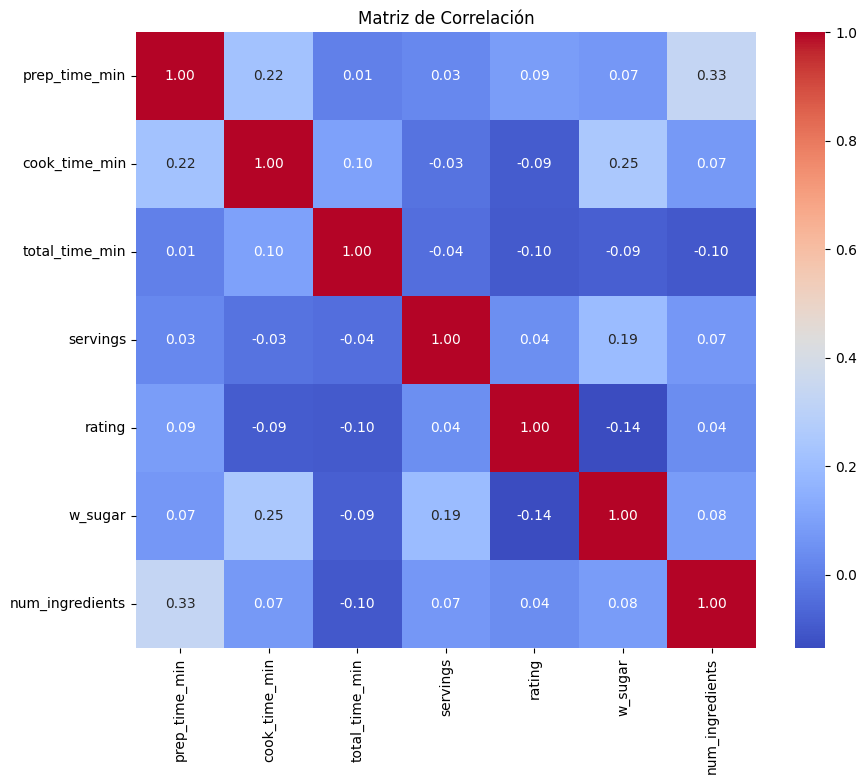

In [56]:
# seleccionar solo columnas numéricas
corr = df.select_dtypes(include='number').corr()

# gráfico
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,      # muestra valores
    cmap='coolwarm', # colores
    fmt=".2f"
)

plt.title("Matriz de Correlación")
plt.show()

In [57]:
df.isna().any()

recipe_name          False
prep_time_min        False
cook_time_min        False
total_time_min       False
servings             False
ingredients          False
directions           False
rating               False
nutrition            False
date                 False
ingredients_list     False
clean_ingredients    False
w_sugar              False
num_ingredients      False
dtype: bool

In [58]:
df.to_csv("/Users/franky/Desktop/Recipe recommender/datasets/recetas_ready.csv", index=False)